In [2]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

Initializing Advanced NLP Pipeline...


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


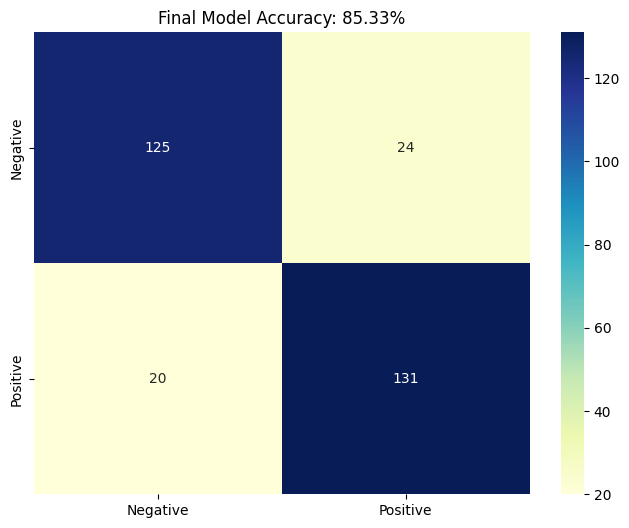

------------------------------
ULTIMATE ACCURACY: 85.33%
------------------------------

Final Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85       149
    Positive       0.85      0.87      0.86       151

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import movie_reviews
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Setup & Advanced Preprocessing
print("Initializing Advanced NLP Pipeline...")
nltk.download('movie_reviews')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove non-alphabetic characters and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    # Lemmatize each word
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

# 2. Load and Clean Data
documents = [(" ".join(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

df = pd.DataFrame(documents, columns=['review', 'sentiment'])
df['review'] = df['review'].apply(clean_text)
df['sentiment'] = df['sentiment'].map({'pos': 1, 'neg': 0})

# 3. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.15, random_state=42 # Slightly more training data
)

# 4. Professional Vectorization
# Increased max_features and used sublinear_tf (standard for high-accuracy NLP)
tfidf = TfidfVectorizer(stop_words='english',
                        max_features=10000,
                        ngram_range=(1, 3), # Added Trigrams (3-word phrases)
                        sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. Model: Linear Support Vector Classification
# SVM is the industry-standard choice for high-accuracy text classification
model = LinearSVC(C=0.5, random_state=42, max_iter=2000)
model.fit(X_train_tfidf, y_train)

# 6. Evaluation
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

# --- VISUALIZATION: Confusion Matrix ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Final Model Accuracy: {accuracy * 100:.2f}%')
plt.show()

print("-" * 30)
print(f"ULTIMATE ACCURACY: {accuracy * 100:.2f}%")
print("-" * 30)
print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))